# Convert Text to Electrical Stimulus Sequence

In [9]:
%reload_ext autoreload
%autoreload 2

# Imports
import numpy as np
import visionloader as vl
import matplotlib.pyplot as plt
import os
import matplotlib.cm as cm
from tqdm import tqdm
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse
import scipy as sp

import sys
sys.path.append("/Volumes/Lab/Users/ajphillips/packages")
import eilib as eil

from quantities import ms, s, Hz
from elephant.spike_train_generation import homogeneous_poisson_process
from elephant.spike_train_dissimilarity import victor_purpura_distance
from neo.core import SpikeTrain

from PIL import Image, ImageDraw, ImageFont
import scipy.spatial.distance as dist

In [12]:
piece = '2024-10-02-7'
analysis_base = f"/Volumes/Stream/Analysis/RETINA/{piece}"
# analysis_base = f"/Volumes/Analysis/{piece}/RETINA"
label = "_2"

wnoise = "data000"
vstim = "data003_from_data000"
cell_types = ['ON parasol', 'OFF parasol']

dict_path = os.path.join(analysis_base, 'dictionary')
vstim_path = os.path.join(analysis_base, vstim)
wnoise_path = os.path.join(analysis_base, wnoise)

### Load electrical stimulus table

In [13]:
selective_stimuli = np.load(os.path.join(dict_path, f"selective_stimuli{label}.npz"))['selective_stimuli'] # selective_stimuli row is [electrode, cell, amp, pure]

### Determine spike trains of interest

In [14]:
wnoise_vcd = vl.load_vision_data(wnoise_path,wnoise,
                        include_neurons=True,
                        include_ei=True,
                        include_params=True,
                        include_runtimemovie_params=True)

coords = wnoise_vcd.get_electrode_map()

In [15]:
# Get all selective cell IDs
cell_ids = np.unique(selective_stimuli[:,1]).astype(int)

In [16]:
def get_smart_stimuli(cell_ids_for_stimulus, selective_stimuli, plot):
    # selective_stimuli row is [electrode, cell, amp, pure]
    # sef row is [time, electrode, amp]

    # Find the selective stimuli that match the cell IDs
    matching_stimuli = []
    for cell_id in cell_ids_for_stimulus:
        matching_stimuli.extend([stimulus for stimulus in selective_stimuli if stimulus[1] == cell_id])
    matching_stimuli = np.array(matching_stimuli)

    # Plot the electrodes
    if plot:
        fig, ax = plt.subplots()
        ax.plot(coords[:,0], coords[:,1], 'k.')

        # Plot the selective electrodes corresponding to each cell_id in different colors
        colors = cm.rainbow(np.linspace(0, 1, len(cell_ids_for_stimulus)))
        for i, cell_id in enumerate(cell_ids_for_stimulus):
            cell_id_elecs = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]][:,0].astype(int)
            ax.plot(coords[cell_id_elecs-1,0], coords[cell_id_elecs-1,1], 'o', color=colors[i])

    # Choose the selective electrode closest to the soma center for each cell
    selected_electrodes = []
    for i, cell_id in enumerate(cell_ids_for_stimulus):
        cell_ei = wnoise_vcd.get_ei_for_cell(cell_id).ei
        ei = np.amin(cell_ei,axis=1)

        # Find soma position
        thresh = -2
        inds = np.argwhere(ei < thresh).flatten()
        soma_inds = []
        soma_ei_vals = []
        for ind in inds:
            if eil.axonorsomaRatio(cell_ei[ind,:]) == 'soma':
                soma_inds.append(ind)
                soma_ei_vals.append(np.min(cell_ei[ind,:]))
        soma_pos = eil.getSomaLocThr(np.array(soma_inds), np.array(soma_ei_vals), coords)

        # Find the selective electrode closest to the soma center
        cell_id_matching_stimuli = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]]
        index = np.argmin(np.linalg.norm(coords[cell_id_matching_stimuli[:,0].astype(int)-1] - soma_pos, axis=1))
        selected_electrode = cell_id_matching_stimuli[index][0].astype(int)
        selected_electrodes.append(selected_electrode)
        # Designate these electrodes on the plot
        if plot:
            ax.plot(coords[selected_electrode-1,0], coords[selected_electrode-1,1], 'X', color=colors[i], markersize=15)

    if plot:
        ax.set_aspect('equal')
        plt.show()

    return np.array(selected_electrodes)

In [17]:
smart_stimuli = get_smart_stimuli(cell_ids, selective_stimuli, plot=False)

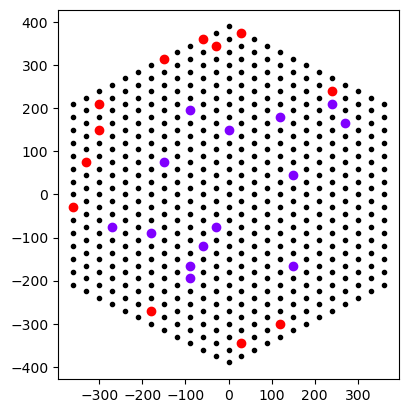

14


In [18]:
# Find the center of mass of the coordinates
center = np.mean(coords, axis=0)

# Make a subset of the smart stimuli that are close to the center
central_smart_stimuli = []
central_cell_ids = []
for i, electrode in enumerate(smart_stimuli):
    if np.linalg.norm(coords[electrode-1] - center) < 320:
        central_smart_stimuli.append(electrode)
        central_cell_ids.append(cell_ids[i])
central_smart_stimuli = np.array(central_smart_stimuli)
central_cell_ids = np.array(central_cell_ids)

# Plot the central smart stimuli and all other smart stimuli in different colors
fig, ax = plt.subplots()
ax.plot(coords[:,0], coords[:,1], 'k.')
colors = cm.rainbow(np.linspace(0, 1, 2))
for i, electrode in enumerate(central_smart_stimuli):
    ax.plot(coords[electrode-1,0], coords[electrode-1,1], 'o', color=colors[0])
for i, electrode in enumerate(smart_stimuli):
    if electrode not in central_smart_stimuli:
        ax.plot(coords[electrode-1,0], coords[electrode-1,1], 'o', color=colors[1])
ax.set_aspect('equal')
plt.show()

print(len(central_smart_stimuli))

In [19]:
pairwise_distances = dist.cdist(coords[central_smart_stimuli-1], coords[central_smart_stimuli-1])

def build_path(pairwise_distance, path):
    if len(path) == len(pairwise_distance):
        return path
    
    valid_neighbors = np.where(pairwise_distance[path[-1]] > 300)[0]

    # Exclude all visited nodes
    valid_neighbors = np.setdiff1d(valid_neighbors, path)

    if len(valid_neighbors) == 0:
        return None
    else:
        for neighbor in valid_neighbors:
            path.append(neighbor)
            new_path = build_path(pairwise_distance, path)
            if new_path is not None:
                return new_path
            path.pop()

    return None
        
path = build_path(pairwise_distances, [0])
print(path)

[0, 3, 1, 2, 7, 13, 5, 9, 6, 12, 4, 10, 8, 11]


In [20]:
for i in range(len(path)-1):
    print(f"Distance between cell {path[i]} and cell {path[i+1]}: {pairwise_distances[path[i]][path[i+1]]}")

# Find average distance between cells
distances = []
for i in range(len(path)-1):
    distances.append(pairwise_distances[path[i]][path[i+1]])
print(f"Average distance between cells: {np.mean(distances)}")

Distance between cell 0 and cell 3: 445.9820624195552
Distance between cell 3 and cell 1: 499.52477416040136
Distance between cell 1 and cell 2: 318.90437438203946
Distance between cell 2 and cell 7: 301.4962686336267
Distance between cell 7 and cell 13: 384.1874542459709
Distance between cell 13 and cell 5: 432.6661530556787
Distance between cell 5 and cell 9: 324.49961479175903
Distance between cell 9 and cell 6: 351.4612354157994
Distance between cell 6 and cell 12: 356.5459297201414
Distance between cell 12 and cell 4: 429.7964634568321
Distance between cell 4 and cell 10: 403.6087214122113
Distance between cell 10 and cell 8: 517.228189487
Distance between cell 8 and cell 11: 384.1874542459709
Average distance between cells: 396.160668878999


In [23]:
central_cell_ids_ordered = central_cell_ids[path]
print(central_cell_ids)
print(central_cell_ids_ordered)

[  46  858 1401 1953 2117 2416 2523 3050 4488 5166 5362 5506 6572 7096]
[  46 1953  858 1401 3050 7096 2416 5166 2523 6572 2117 5362 4488 5506]


(17,)


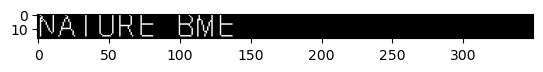

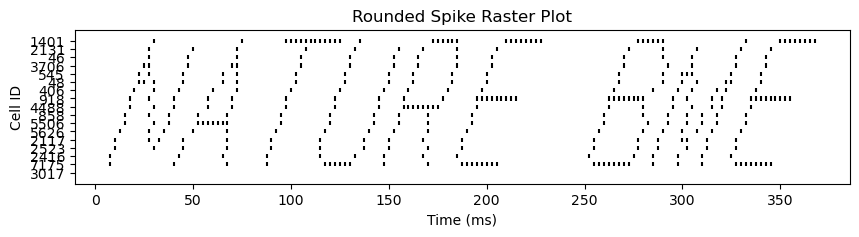

In [146]:
# Set the dimensions of the image
width = 350
height = central_cell_ids_ordered.size

# Create a blank white background
background_color = (255, 255, 255)  # White color
image = Image.new("RGB", (width, height), background_color)

# Create a draw object
draw = ImageDraw.Draw(image)

# Set the font properties
font_path = "/usr/share/fonts/truetype/liberation/LiberationSans-Italic.ttf"  # Replace with the path to your font file
font_path = "/usr/share/fonts/truetype/ubuntu-font-family/UbuntuMono-RI.ttf"
font_path = "/usr/share/fonts/truetype/droid/DroidSansMono.ttf"
font_size = 24

# Load the font
font = ImageFont.truetype(font_path, font_size)

# Set the text properties
text = "I LOVE YOU" # I LOVE YOU BROOKE STANFORD RETINA SPIKES VISION PHILLIPS ET AL ZAPIS DU KARTY NEURONS NATURE BME
text_color = (0, 0, 0)  # Black color
text_position = (0, -6)  # Replace with the desired position of the text

# Write the text on the image
draw.text(text_position, text, font=font, fill=text_color)

# Set the text properties
# text = "CARDINAL"
# text_color = (0, 0, 0)  # Black color
# text_position = (0, 15)  # Replace with the desired position of the text

# Write the text on the image
# draw.text(text_position, text, font=font, fill=text_color)

# Assign the resulting image matrix to a variable
result = np.array(image)[:,:,0]

# display the matrix as an image
plt.imshow(result, cmap='gray')

# round all values to 0 or 255
result = np.round(result / 255) * 255

# reduce the boundary of the connected components
from skimage import morphology
skeleton = morphology.skeletonize(result == 0)
plt.imshow(skeleton, cmap='gray')

# for each row, convert skeleton to a list of y-coordinates of True values
y_coords = []
for row in skeleton:
    y_coords.append(np.where(row)[0])
y_coords = np.flip(np.array(y_coords, dtype=object), axis=0)

# get maximum y coordinate overall
max_y = -1
for y in y_coords:
    if len(y) > 0:
        max_y = max(max_y, y[-1])

scaled_y_coords = [y * 2.5 for y in y_coords]

for i, cell_spike_times in enumerate(scaled_y_coords):
    if len(cell_spike_times) < 2:
        continue
    intervals = np.diff(cell_spike_times)
    skip_indices = np.where(intervals <= 2.5)[0] + 1
    skip_indices = [skip for skip in skip_indices if skip % 2 != 0]
    # scaled_y_coords[i] = np.delete(scaled_y_coords[i], skip_indices)

# shift every consecutive row by an additional 2.5 ms
for i in range(1, len(scaled_y_coords)):
    scaled_y_coords[i] += i * 1.5

bin_size_ms = 2.5
rounded_response = np.array([np.round(cell_spike_times / bin_size_ms) * bin_size_ms for cell_spike_times in scaled_y_coords], dtype=object)

# shift every consecutive row by an additional 2.5 ms
# for i in range(1, len(rounded_response)):
#     rounded_response[i] += i * 2.5

print(rounded_response.shape)

plt.figure(figsize=(10, 2))

# Create a spike raster plot
plt.eventplot(rounded_response, linelengths=0.5, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(central_cell_ids_ordered)), central_cell_ids_ordered)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Rounded Spike Raster Plot')

# Show the plot
plt.show()

In [ ]:
# Randomly remove 20% of the spikes from rounded_response
for i in range(len(rounded_response)):
    num_spikes = len(rounded_response[i])
    num_spikes_to_remove = int(num_spikes * 0.2)
    indices_to_remove = np.random.choice(num_spikes, num_spikes_to_remove, replace=False)
    rounded_response[i] = np.delete(rounded_response[i], indices_to_remove)

plt.figure(figsize=(10, 2))

# Create a spike raster plot
plt.eventplot(rounded_response, linelengths=0.5, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(central_cell_ids_ordered)), central_cell_ids_ordered)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Rounded Spike Raster Plot with 20% Spikes Removed')

# Show the plot
plt.show()

In [31]:
from collections import Counter

def assign_stimuli_to_responses(response, cell_ids, selective_stimuli, plot=False):
    # responses is a list of arrays of spike times for each cell
    # cell_ids is an array of cell IDs
    # selective_stimuli is an array of selective stimuli

    concat_response = np.concatenate(response)

    # max_n = Counter(concat_response).most_common(1)[0][1]
    # print(f"Maximum number of simultaneous cells firing: {max_n}")

    concat_spike_times = np.unique(concat_response)
    print(f"Unique stimulus times: {concat_spike_times.size}")

    if concat_spike_times.size == 0:
        return np.array([[0, 2, 0.09375]])

    sef = np.empty((0,3))
    crowded_count = 0

    for t in concat_spike_times:
        print("-------------------")
        print(f"Stimulus time: {t}")
        # Determine which of the response arrays contain the stimulus time
        response_indices = [i for i, cell_spike_times in enumerate(response) if t in cell_spike_times]
        cell_ids_for_stimulus = cell_ids[response_indices]
        print(f"Cell IDs: {cell_ids_for_stimulus}")
        # Report and remove any cell IDs that are not in the selective stimuli
        if len([cell_id for cell_id in cell_ids_for_stimulus if cell_id not in selective_stimuli[:,1]]) > 0:
            print(f"Can't selectively stimulate cell IDs: {[cell_id for cell_id in cell_ids_for_stimulus if cell_id not in selective_stimuli[:,1]]}")
        cell_ids_for_stimulus = np.array([cell_id for cell_id in cell_ids_for_stimulus if cell_id in selective_stimuli[:,1]])

        # Continue if there are no cell IDs to stimulate
        if cell_ids_for_stimulus.size == 0:
            print("Skipping stimulus time...")
            continue

        # sef = np.vstack((sef, assign_stimuli(t, cell_ids_for_stimulus, selective_stimuli, plot))) # IMPORTANT SMART OR NOT CHANGE
        sef_row, crowded = assign_stimuli_smart(t, cell_ids_for_stimulus, selective_stimuli, plot)
        sef = np.vstack((sef, sef_row))
        if crowded:
            crowded_count += 1

    print("-------------------")
    print(f"{crowded_count / len(concat_spike_times) * 100:.1f}% crowded stimuli")

    return sef


def assign_stimuli(t, cell_ids_for_stimulus, selective_stimuli, plot):
    # selective_stimuli row is [electrode, cell, amp, pure]
    # sef row is [time, electrode, amp]

    # Find the selective stimuli that match the cell IDs
    matching_stimuli = []
    for cell_id in cell_ids_for_stimulus:
        matching_stimuli.extend([stimulus for stimulus in selective_stimuli if stimulus[1] == cell_id])
    matching_stimuli = np.array(matching_stimuli)

    if len(cell_ids_for_stimulus) == 1:
        print(f"Selected electrodes: {matching_stimuli[0,0].astype(int)}")
        return [t, matching_stimuli[0,0], matching_stimuli[0,2]]

    # Find the convex hull of the electrodes in the matching stimuli on the electrode array
    electrodes = np.array([stimulus[0] for stimulus in matching_stimuli])
    electrodes = electrodes.astype(int)

    if len(electrodes) == 2:
        print(f"Selected electrodes: {electrodes.astype(int)}")
        return np.array([[t, matching_stimuli[0,0], matching_stimuli[0,2]], 
                        [t, matching_stimuli[1,0], matching_stimuli[1,2]]])

    # Plot the electrodes
    if plot:
        fig, ax = plt.subplots()
        ax.plot(coords[:,0], coords[:,1], 'k.')

        # Plot the selective electrodes corresponding to each cell_id in different colors
        colors = cm.rainbow(np.linspace(0, 1, len(cell_ids_for_stimulus)))
        for i, cell_id in enumerate(cell_ids_for_stimulus):
            cell_id_elecs = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]][:,0].astype(int)
            ax.plot(coords[cell_id_elecs-1,0], coords[cell_id_elecs-1,1], 'o', color=colors[i])

    # For the first two cells, find an electrode for each of the cells that activates the cell and is farthest away from the other found electrode
    selected_electrodes = []
    cell_id_elecs0 = matching_stimuli[np.where(matching_stimuli[:,1] == cell_ids_for_stimulus[0])[0]][:,0].astype(int)
    cell_id_elecs1 = matching_stimuli[np.where(matching_stimuli[:,1] == cell_ids_for_stimulus[1])[0]][:,0].astype(int)
    distances = sp.spatial.distance.cdist(coords[cell_id_elecs0-1], coords[cell_id_elecs1-1])
    index = np.unravel_index(np.argmax(distances), distances.shape)
    selected_electrode = cell_id_elecs0[index[0]]
    selected_electrodes.append(selected_electrode)
    # Designate these electrodes on the plot
    if plot:
        ax.plot(coords[selected_electrode-1,0], coords[selected_electrode-1,1], 'X', color=colors[0], markersize=15)
    selected_electrode = cell_id_elecs1[index[1]]
    selected_electrodes.append(selected_electrode)
    # Designate these electrodes on the plot
    if plot:
        ax.plot(coords[selected_electrode-1,0], coords[selected_electrode-1,1], 'X', color=colors[1], markersize=15)


    # Find an electrode for each of the remaining cell IDs that activates the cell and is farthest away from all other found electrodes
    for i, cell_id in enumerate(cell_ids_for_stimulus):
        if i < 2:
            continue
        cell_id_elecs = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]][:,0].astype(int)
        distances = sp.spatial.distance.cdist(coords[cell_id_elecs-1], coords[np.array(selected_electrodes)-1])
        index = np.argmax(np.sum(distances, axis=1))
        selected_electrode = cell_id_elecs[index]
        selected_electrodes.append(selected_electrode)
        # Designate these electrodes on the plot
        if plot:
            ax.plot(coords[selected_electrode-1,0], coords[selected_electrode-1,1], 'X', color=colors[i], markersize=15)

    if plot:
        ax.set_aspect('equal')
        plt.show()

    print(f"Selected electrodes: {selected_electrodes}")

    to_return = np.empty((0,3))
    for i, cell_id in enumerate(cell_ids_for_stimulus):
        to_return = np.vstack((to_return, [t, selected_electrodes[i], matching_stimuli[np.where(matching_stimuli[:,0:1] == [selected_electrodes[i], cell_id])[0][0],2]]))
    return to_return


def assign_stimuli_smart(t, cell_ids_for_stimulus, selective_stimuli, plot):
    # selective_stimuli row is [electrode, cell, amp, pure]
    # sef row is [time, electrode, amp]

    # Find the selective stimuli that match the cell IDs
    matching_stimuli = []
    for cell_id in cell_ids_for_stimulus:
        matching_stimuli.extend([stimulus for stimulus in selective_stimuli if stimulus[1] == cell_id])
    matching_stimuli = np.array(matching_stimuli)

    # Plot the electrodes
    if plot:
        fig, ax = plt.subplots()
        ax.plot(coords[:,0], coords[:,1], 'k.')

        # Plot the selective electrodes corresponding to each cell_id in different colors
        colors = cm.rainbow(np.linspace(0, 1, len(cell_ids_for_stimulus)))
        for i, cell_id in enumerate(cell_ids_for_stimulus):
            cell_id_elecs = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]][:,0].astype(int)
            ax.plot(coords[cell_id_elecs-1,0], coords[cell_id_elecs-1,1], 'o', color=colors[i])

    # Choose the selective electrode closest to the soma center for each cell
    selected_electrodes = []
    for i, cell_id in enumerate(cell_ids_for_stimulus):
        cell_ei = wnoise_vcd.get_ei_for_cell(cell_id).ei
        ei = np.amin(cell_ei,axis=1)

        # Find soma position
        thresh = -2
        inds = np.argwhere(ei < thresh).flatten()
        soma_inds = []
        soma_ei_vals = []
        for ind in inds:
            if eil.axonorsomaRatio(cell_ei[ind,:]) == 'soma':
                soma_inds.append(ind)
                soma_ei_vals.append(np.min(cell_ei[ind,:]))
        soma_pos = eil.getSomaLocThr(np.array(soma_inds), np.array(soma_ei_vals), coords)

        # Find the selective electrode closest to the soma center
        cell_id_matching_stimuli = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]]
        index = np.argmin(np.linalg.norm(coords[cell_id_matching_stimuli[:,0].astype(int)-1] - soma_pos, axis=1))
        selected_electrode = cell_id_matching_stimuli[index][0].astype(int)
        selected_electrodes.append(selected_electrode)
        # Designate these electrodes on the plot
        if plot:
            ax.plot(coords[selected_electrode-1,0], coords[selected_electrode-1,1], 'X', color=colors[i], markersize=15)

    if plot:
        ax.set_aspect('equal')
        plt.show()

    print(f"Selected electrodes: {selected_electrodes}")

    # Print warning if any of the selected electrodes are closer than 200 microns
    crowded = False
    distances = sp.spatial.distance.cdist(coords[np.array(selected_electrodes)-1], coords[np.array(selected_electrodes)-1])
    np.fill_diagonal(distances, np.inf)
    if np.min(distances) < 100:
        print(f"WARNING: Selected electrodes are minimum {np.min(distances):.0f} microns apart")
        crowded = True

    to_return = np.empty((0,3))
    for i, cell_id in enumerate(cell_ids_for_stimulus):
        to_return = np.vstack((to_return, [t, selected_electrodes[i], matching_stimuli[np.where(matching_stimuli[:,0:1] == [selected_electrodes[i], cell_id])[0][0],2]]))
    return to_return, crowded


def convert_sef_to_board(sef):
    amplitudes = np.array([0.09375, 0.1875, 0.28125, 0.375, 0.46875, 0.5625, 0.65625, 0.75, 0.84375, 0.9375,
            1.03125, 1.125, 1.21875, 1.3125, 1.40625, 1.5, 1.59375, 1.6875, 1.78125, 1.875, 1.96875,
            2.0625, 2.15625, 2.25, 2.34375, 2.4375, 2.53125, 2.625, 2.71875, 2.8125, 2.90625, 3.0,
            3.09375, 3.1875, 3.28125, 3.375, 3.46875, 3.5625, 3.65625, 3.75, 3.84375, 3.9375])

    # Subtract time 0 from all times
    board_sef = sef.copy()
    board_sef[:,0] -= board_sef[0,0]
    board_sef[:,0] *= 20

    # Avoid multiples of the stimulation window boundary
    board_sef[:,0] += 1

    # Find the index of the closest amplitude to the amplitude in the sef
    for i in range(board_sef.shape[0]):
        board_sef[i,2] = np.argmin(np.abs(amplitudes - board_sef[i,2])) + 1 # 1-indexed

    board_sef = board_sef.astype(int)
    return board_sef

def transform_from_519(electrodes):
    skip_elecs = np.array([1, 130, 259, 260, 389, 390, 519])
    elecs = np.arange(1, 520)
    elecs = elecs[~np.isin(elecs, skip_elecs)]

    patterns = []
    for electrode in electrodes:
        patterns.append(np.where(elecs == electrode)[0][0] + 1)
    return np.array(patterns)

In [186]:
# randomize the order of the cell IDs
np.random.shuffle(central_cell_ids_ordered)
print(central_cell_ids_ordered)

[ 545 4488 1401 2523 7175 2416 5626 3017  918   46 2117  858 2131   48
 3706  406 5506]


In [187]:
sef = convert_sef_to_board(assign_stimuli_to_responses(rounded_response,central_cell_ids_ordered,selective_stimuli,plot=False))

Unique stimulus times: 132
-------------------
Stimulus time: 7.5
Cell IDs: [4488 1401]
Selected electrodes: [115, 98]
-------------------
Stimulus time: 10.0
Cell IDs: [2523 7175]
Selected electrodes: [191, 443]
-------------------
Stimulus time: 12.5
Cell IDs: [2416]
Selected electrodes: [162]
-------------------
Stimulus time: 15.0
Cell IDs: [5626 3017]
Selected electrodes: [363, 309]
-------------------
Stimulus time: 17.5
Cell IDs: [918  46]
Selected electrodes: [45, 9]
-------------------
Stimulus time: 20.0
Cell IDs: [2117]
Selected electrodes: [150]
-------------------
Stimulus time: 22.5
Cell IDs: [ 858 2131]
Selected electrodes: [58, 287]
-------------------
Stimulus time: 25.0
Cell IDs: [858  48]
Selected electrodes: [58, 504]
-------------------
Stimulus time: 27.5
Cell IDs: [7175 2416 3017   46 2131   48 3706  406]
Selected electrodes: [443, 162, 309, 9, 287, 504, 279, 33]
-------------------
Stimulus time: 30.0
Cell IDs: [2523 5626  918 2117  858 5506]
Selected electrodes

In [33]:
# all_sef_arrays = []
# all_ordered_cell_ids = []
# all_text = []

If you are ready to accept the text, run below.

In [188]:
sef[:,1] = transform_from_519(sef[:,1])
all_sef_arrays.append(sef)
all_ordered_cell_ids.append(central_cell_ids_ordered)
all_text.append(text)

In [189]:
print(len(all_sef_arrays))
print(len(all_ordered_cell_ids))
print(len(all_text))
print(all_text)

10
10
10
['I LOVE YOU', 'BROOKE', 'STANFORD', 'RETINA', 'SPIKES', 'VISION', 'PHILLIPS ET AL', 'ZAPIS DU KARTY', 'NEURONS', 'NATURE BME']


In [190]:
num_repeats = 15
all_sef_arrays_repeat = [sef.astype(np.int32) for sef in all_sef_arrays for _ in range(num_repeats)]

In [191]:
# Add 300 to the first SEF sequence to give adequate time for the initial current range setting [1 0 -4]
all_sef_arrays_repeat[0][:,0] += 300
all_sef_arrays_repeat = np.array(all_sef_arrays_repeat, dtype=object)

save_path = os.path.join(dict_path, f"spike_trains_text{label}.npz")
np.savez(save_path, sef=all_sef_arrays_repeat, text=all_text, order=all_ordered_cell_ids, allow_pickle=True)